# 01 — Time Series Preparation

Turns the raw pickle of 4,437 per-subject actigraphy recordings into the four
NumPy arrays every later notebook loads. Six steps:

1. **Load** — read the pickled list of per-subject DataFrames.
2. **Split** — stratified 80/20 at *subject* level, before anything
   data-dependent happens.
3. **Filter outliers** — a per-channel Hampel filter blanks out sensor spikes.
4. **Impute** — linear interpolation fills the holes the filter left.
5. **Normalise** — Z-score each channel using training statistics only.
6. **Save** — stack into 3-D arrays and write them to `dataset/`.

The implementation lives in `src/`; this notebook is the driver.

Equivalent to: `python main.py --stage prep`

In [1]:
# Make the project's src/ package importable from inside notebooks/.
import os
import sys
sys.path.insert(0, os.path.abspath(".."))

import warnings
warnings.filterwarnings("ignore")

from src.data_loader import (build_split, build_subject_metadata,
                             describe_split, fit_feature_scalers,
                             impute_missing, load_raw_dataset,
                             normalize_subjects, remove_outliers_hampel,
                             save_outlier_log, save_prepared_arrays,
                             split_subjects)
from src.plots import (plot_normalization_effect, plot_outlier_treatment,
                       plot_stl_decomposition)

## 1. Load the raw dataset

Each subject is one DataFrame: 200 rows of 30-minute averages (about 4.2 days
of continuous wear) across the sensor channels, plus the subject `id` and the
binarised target `sii_binary`.

In [2]:
dataset = load_raw_dataset()
print(f"Loaded {len(dataset)} subject time series.")

dataset[0]

Loaded 4437 subject time series.


,X,Y,Z,enmo,anglez,non-wear_flag,light,battery_voltage,weekday,quarter,relative_date_PCIAT,id,sii_binary
0,-0.696639,-0.058477,-0.086717,0.051424,-6.090168,0.0,21.794674,4023.000000,4.0,4.0,253.0,2265,0
1,-0.479150,0.218840,-0.289497,0.062909,-19.893288,0.0,20.835835,4023.000000,4.0,4.0,253.0,2265,0
2,-0.440287,-0.171177,-0.326227,0.121546,-23.043303,0.0,6.294650,4023.000000,4.0,4.0,253.0,2265,0
3,-0.559035,-0.293204,-0.145227,0.084953,-9.694811,0.0,0.462963,4022.616699,4.0,4.0,253.0,2265,0
4,-0.531364,-0.210126,-0.086370,0.074157,-6.412807,0.0,4.058062,4020.583252,4.0,4.0,253.0,2265,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,0.217219,-0.049072,-0.677605,0.023341,-48.641335,0.0,23.635958,4000.000000,4.0,4.0,253.0,2265,0
196,-0.114495,0.255887,-0.221531,0.043775,-15.998703,0.0,0.424431,4000.000000,4.0,4.0,253.0,2265,0
197,-0.330821,0.617914,0.084195,0.021643,5.085504,0.0,0.023987,4000.000000,4.0,4.0,253.0,2265,0
198,-0.074080,0.543216,-0.031553,0.017400,-2.606687,0.0,0.041618,4000.000000,4.0,4.0,253.0,2265,0


## 2. Train / test split

The split happens at **subject** level, never at time-step level: all 200 rows
of a child move together, so no part of a test subject is ever seen during
training. Stratifying on `sii_binary` keeps the 2:1 class ratio in both halves.

Five columns are dropped from the features. `sii_binary` is the target;
`weekday`, `quarter` and `relative_date_PCIAT` are calendar metadata rather
than sensor signal; and `id` is a static per-subject tracker that a model could
simply memorise.

In [3]:
subject_metadata = build_subject_metadata(dataset)
train_metadata, test_metadata = split_subjects(subject_metadata)

train_frames, y_train = build_split(dataset, train_metadata)
test_frames, y_test = build_split(dataset, test_metadata)

describe_split(y_train, y_test)
print("-" * 50)
print("Features remaining in train set:", train_frames[0].columns.tolist())

Train X size (Subjects): 3549 | Train y size (Labels): 3549
Test X size (Subjects):  888 | Test y size (Labels):  888
--------------------------------------------------
Train set class distribution:
  Class 0: 2365 elements (66.64%)
  Class 1: 1184 elements (33.36%)
Test set class distribution:
  Class 0: 592 elements (66.67%)
  Class 1: 296 elements (33.33%)
--------------------------------------------------
Features remaining in train set: ['X', 'Y', 'Z', 'enmo', 'anglez', 'non-wear_flag', 'light', 'battery_voltage']


## 3. Missing values

Worth checking before deciding on an imputation strategy — and the answer here
is that the dataset arrives complete. Every NaN dealt with later is one this
notebook creates on purpose, by removing an outlier.

In [4]:
total_missing = sum(frame.isna().sum().sum() for frame in dataset)
print(f"Total missing values across the entire dataset: {total_missing}")

Total missing values across the entire dataset: 0


## 4. Outliers — the Hampel filter

Outliers are handled *before* decomposition or modelling: a single sensor spike
would otherwise distort the trend line, the population standard deviation, and
every distance computed later.

The Hampel filter slides a rolling median along each channel and flags any
point sitting more than `sigma` scaled median-absolute-deviations away from it.
Window and sigma are tuned per channel in `src/config.py` — spikier channels
get a looser sigma, the slow-moving battery trace gets a wider window.

Two columns are excluded: a rolling median over the binary `non-wear_flag`
would be meaningless, and `id` is a constant tracker.

**Only the training subjects are filtered.** The test subjects keep their raw
values, so nothing about the held-out set is ever touched.

This cell is the slow one in the notebook — roughly 25,000 filter fits.

In [5]:
cleaned_frames, outlier_records = remove_outliers_hampel(train_frames)
save_outlier_log(outlier_records)

All 175372 filtered outliers are saved to: '/Users/alessandro/Documents/NEW PROJECT/Local_DM2_Project/timeseries/dataset/detected_outliers.csv'


## 5. Imputation

Flagged points are now NaN. Linear interpolation reconnects the signal across
each gap, and a trailing forward/backward fill catches gaps at the very start
or end of a series, where interpolation has no value on one side to work from.

The figure below traces one channel through all three states: raw with the
flagged points marked, hollowed out, and finally patched.

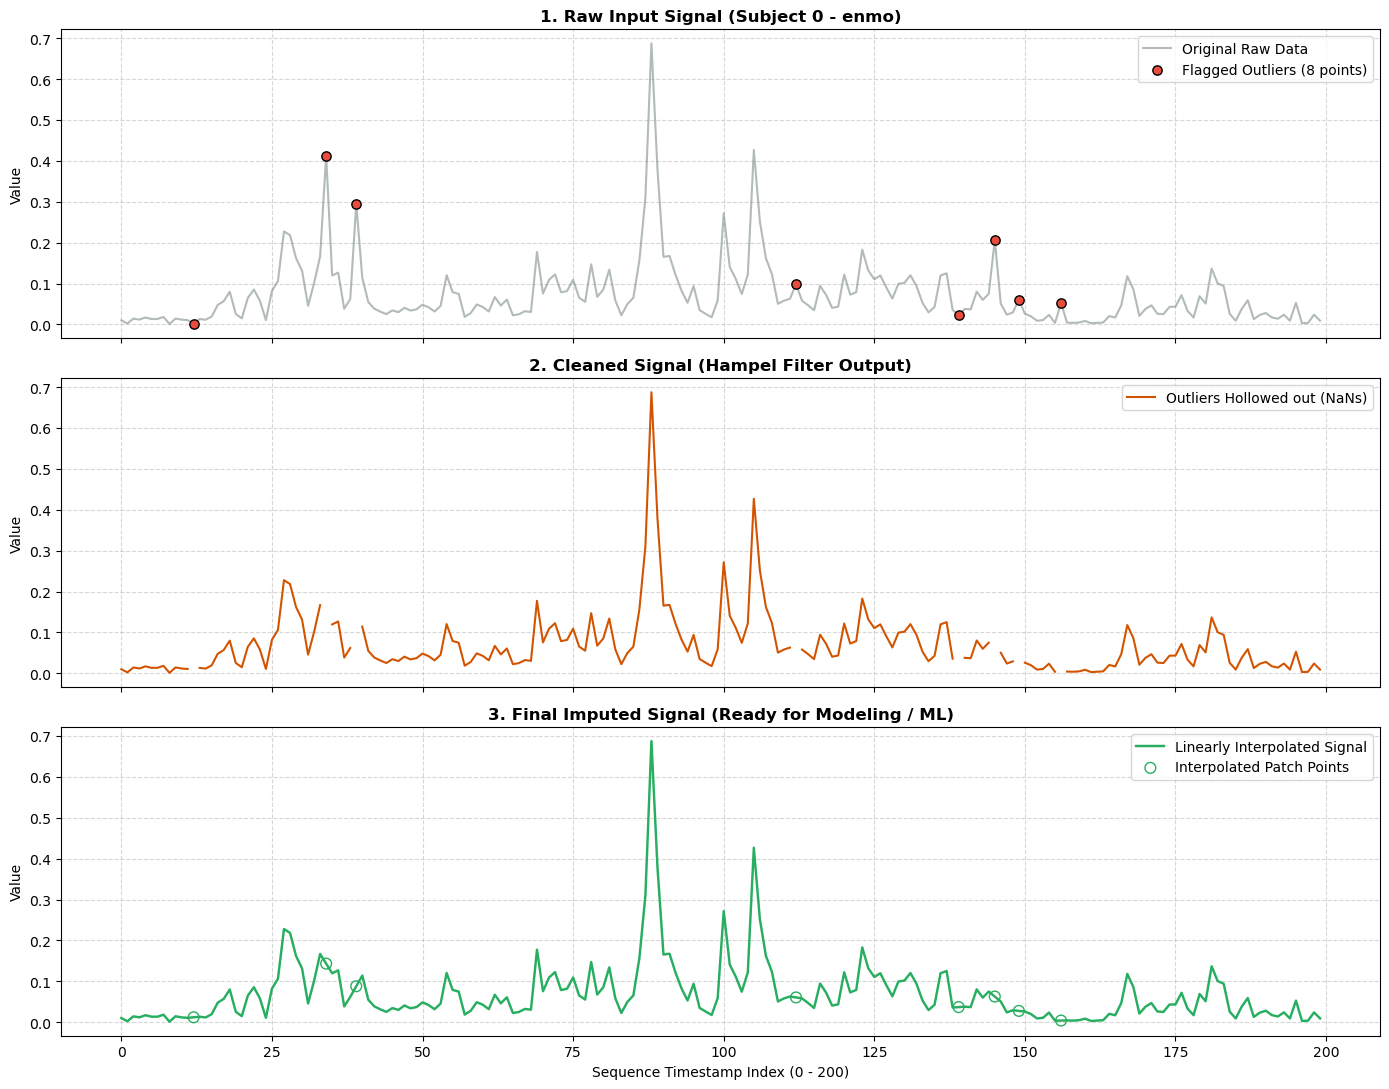

In [6]:
imputed_frames = impute_missing(cleaned_frames)

plot_outlier_treatment(train_frames, cleaned_frames, imputed_frames)

## 6. Time series decomposition

A diagnostic rather than a pipeline step. STL splits a signal into three
additive parts — a slow trend, a repeating daily cycle, and whatever is left
over as noise. With a period of 48 half-hour steps, the "seasonal" component is
literally the child's daily routine.

All four panels share one Y-scale, so the relative size of each component is
readable at a glance.

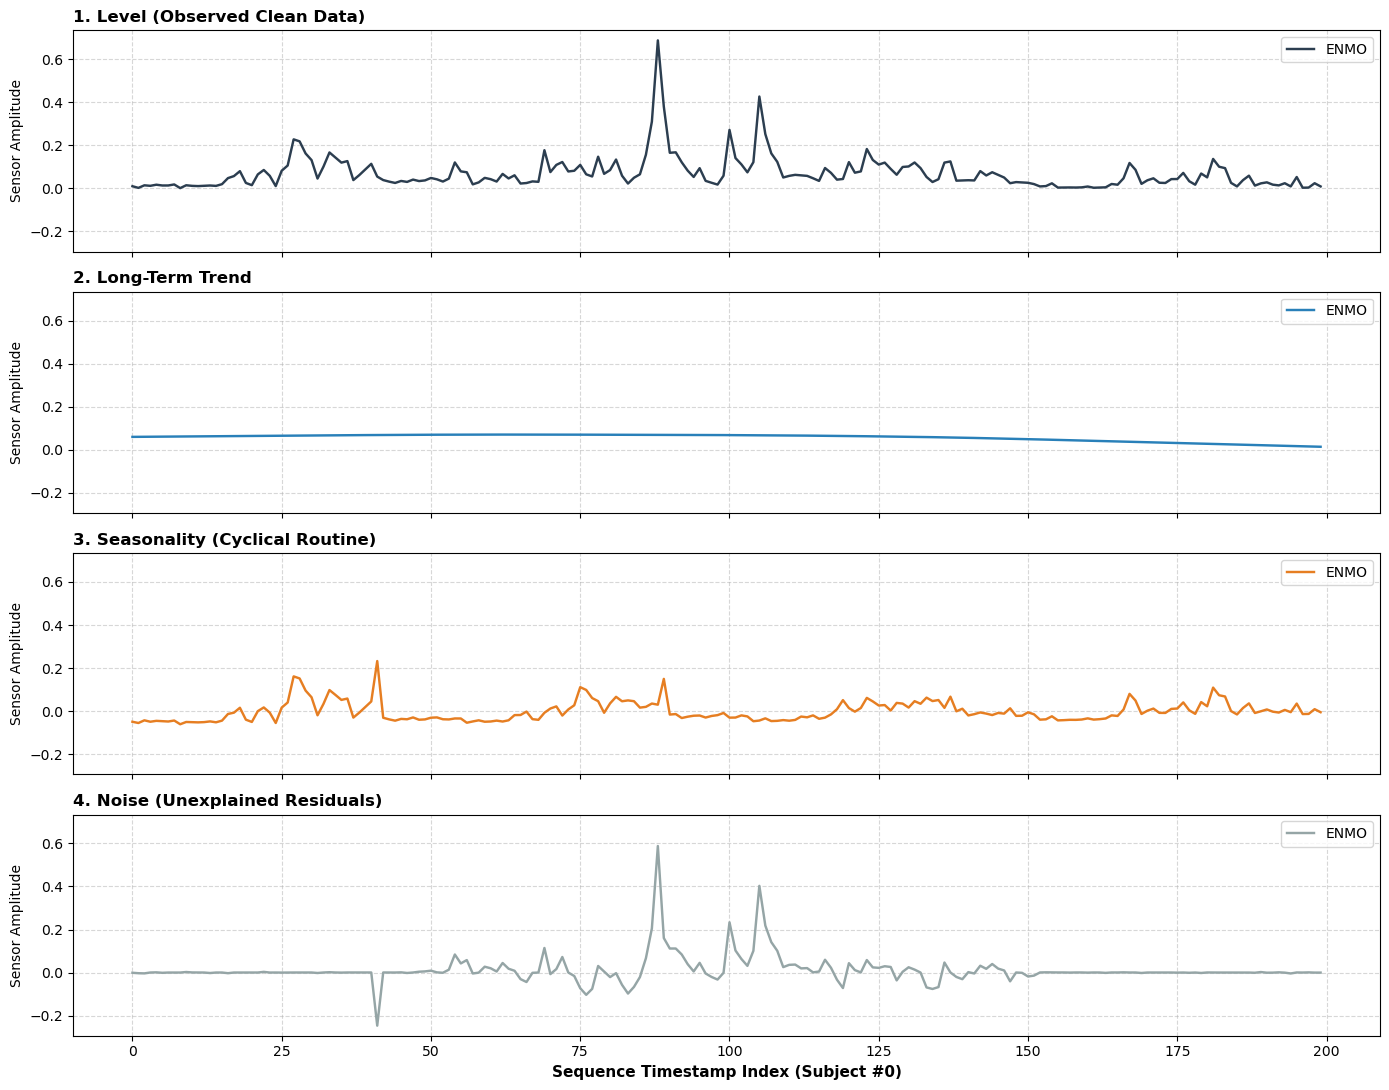

In [7]:
plot_stl_decomposition(imputed_frames)

## 7. Normalisation

Z-score normalisation, chosen because the classifiers used later (k-NN, DTW,
shapelets) all measure *distance* between points. Z-scoring strips out the
baseline offset that differs between devices and bodies while preserving the
shape and relative size of the activity peaks — which is the part that carries
behavioural meaning.

Each channel gets its own scaler, fitted on all training subjects stacked end
to end so the statistics are population-level rather than per-child. The test
set is transformed with those same scalers and never contributes to them.

`non-wear_flag` is left alone: standardising a 0/1 indicator would destroy its
meaning.

In [8]:
scalers = fit_feature_scalers(imputed_frames)

train_normalized = normalize_subjects(imputed_frames, scalers)
test_normalized = normalize_subjects(test_frames, scalers)

print(f"Normalized Train Set: {len(train_normalized)} subjects")
print(f"Normalized Test Set:  {len(test_normalized)} subjects")

Normalized Train Set: 3549 subjects
Normalized Test Set:  888 subjects


The figure makes the point concretely: two children whose raw traces sit at
completely different baselines become directly comparable once standardised.

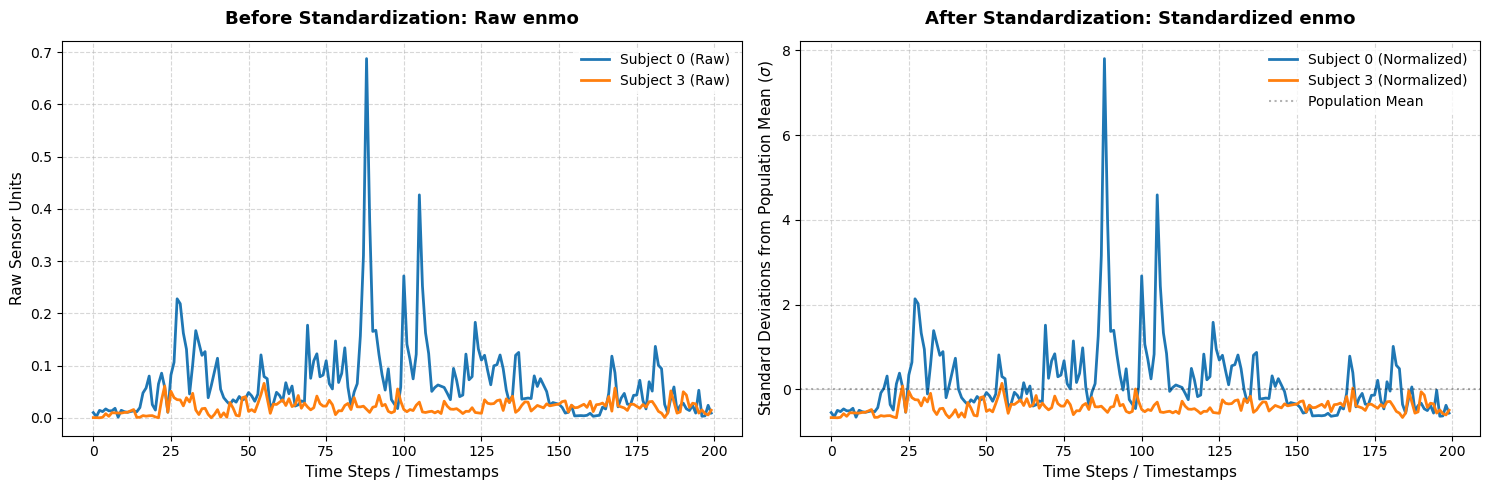

In [9]:
plot_normalization_effect(imputed_frames, train_normalized)

## 8. Save

Stack the per-subject frames into 3-D arrays of shape
`(n_subjects, 200, 8)` — subjects, time steps, features — and write them
alongside the labels. Every later notebook starts by loading these four files.

In [10]:
save_prepared_arrays(train_normalized, test_normalized, y_train, y_test)

Successfully saved preprocessed datasets!
train_features.npy shape: (3549, 200, 8)
test_features.npy shape:  (888, 200, 8)
train_labels.npy shape: (3549,)
test_labels.npy shape:  (888,)


(array([[[ 0.42172518, -0.23449084,  1.6257241 , ...,  0.        ,
           2.4785843 ,  1.412933  ],
         [ 1.8915507 , -0.8145406 ,  0.79934907, ...,  0.        ,
           2.5106645 ,  1.412933  ],
         [ 0.6882803 , -1.4185675 , -0.24521989, ...,  0.        ,
           2.5481086 ,  1.412933  ],
         ...,
         [-0.99539876, -0.14816087, -1.5898364 , ...,  0.        ,
          -0.24365409,  1.2718265 ],
         [-0.24284412, -1.3351325 , -1.2711676 , ...,  0.        ,
          -0.24347897,  1.2718265 ],
         [ 1.143854  ,  1.1867282 , -1.1412673 , ...,  0.        ,
          -0.243416  ,  1.2718265 ]],
 
        [[ 0.9848742 ,  1.4398992 ,  0.514598  , ...,  0.        ,
          -0.2281537 , -0.28034502],
         [-0.04215409,  1.4398992 ,  0.45369625, ...,  0.        ,
          -0.22735421, -0.28034502],
         [ 0.00564684,  1.2341546 ,  0.3927945 , ...,  0.        ,
          -0.22704408, -0.28034502],
         ...,
         [-0.70668125,  0.6919207